# エンコーディングフォーマットのベンチマーキング（サイズ）
JSON / JSON+GZIP / CBOR / MessagePack / Protocol Buffers / ASN.1

In [1]:
!pip install cbor2 msgpack asn1 asn1tools protobuf grpcio-tools -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.5/864.5 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 whi

In [2]:
import json, gzip, cbor2, msgpack, asn1, asn1tools
import struct
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

import subprocess, sys
from google.protobuf import descriptor_pb2

## サンプルデータ (5種類)

In [3]:
samples = {
    # 1. シンプルなユーザー情報
    "simple_user": {
        "id": 1,
        "name": "Alice",
        "age": 30,
        "active": True
    },

    # 2. ネストした注文データ
    "nested_order": {
        "order_id": "ORD-2024-001",
        "customer": {"name": "Bob", "email": "bob@example.com"},
        "items": [
            {"sku": "A001", "qty": 2, "price": 19.99},
            {"sku": "B002", "qty": 1, "price": 49.50},
        ],
        "total": 89.48
    },

    # 3. 数値配列 (センサーデータ)
    "sensor_data": {
        "sensor_id": "sensor_42",
        "timestamp": 1700000000,
        "readings": [23.1, 23.4, 23.0, 22.8, 23.5, 24.1, 23.9, 23.2, 22.7, 23.6]
    },

    # 4. テキスト多め (ログエントリ)
    "log_entry": {
        "level": "ERROR",
        "message": "Connection timeout: failed to reach database server after 30 seconds",
        "host": "web-server-01.internal",
        "trace": "at connect() line 42 in db.py",
        "tags": ["database", "timeout", "critical"]
    },

    # 5. 大きめのリスト (商品カタログ)
    "product_catalog": {
        "catalog_id": "CAT-2024",
        "products": [
            {"id": i, "name": f"Product {i}", "price": round(9.99 + i * 1.5, 2), "in_stock": i % 2 == 0}
            for i in range(20)
        ]
    }
}

for name, data in samples.items():
    print(f"{name}: {json.dumps(data, ensure_ascii=False)[:80]}...")

simple_user: {"id": 1, "name": "Alice", "age": 30, "active": true}...
nested_order: {"order_id": "ORD-2024-001", "customer": {"name": "Bob", "email": "bob@example.c...
sensor_data: {"sensor_id": "sensor_42", "timestamp": 1700000000, "readings": [23.1, 23.4, 23....
log_entry: {"level": "ERROR", "message": "Connection timeout: failed to reach database serv...
product_catalog: {"catalog_id": "CAT-2024", "products": [{"id": 0, "name": "Product 0", "price": ...


# スキーマ定義

In [4]:
# --- Proto定義 ---
protos = {
    "simple_user": ("""
syntax = "proto3";
message SimpleUser { int32 id = 1; string name = 2; int32 age = 3; bool active = 4; }
""", "SimpleUser"),

    "nested_order": ("""
syntax = "proto3";
message Customer { string name = 1; string email = 2; }
message Item { string sku = 1; int32 qty = 2; double price = 3; }
message NestedOrder { string order_id = 1; Customer customer = 2; repeated Item items = 3; double total = 4; }
""", "NestedOrder"),

    "sensor_data": ("""
syntax = "proto3";
message SensorData { string sensor_id = 1; int64 timestamp = 2; repeated double readings = 3; }
""", "SensorData"),

    "log_entry": ("""
syntax = "proto3";
message LogEntry { string level = 1; string message = 2; string host = 3; string trace = 4; repeated string tags = 5; }
""", "LogEntry"),

    "product_catalog": ("""
syntax = "proto3";
message Product { int32 id = 1; string name = 2; double price = 3; bool in_stock = 4; }
message ProductCatalog { string catalog_id = 1; repeated Product products = 2; }
""", "ProductCatalog"),
}

# コンパイル
import os
os.makedirs("proto_out", exist_ok=True)

for sample_name, (proto_content, _) in protos.items():
    with open(f"{sample_name}.proto", "w") as f:
        f.write(proto_content)
    subprocess.run([
        sys.executable, "-m", "grpc_tools.protoc",
        "-I.", f"--python_out=proto_out", f"{sample_name}.proto"
    ], check=True)

sys.path.insert(0, "proto_out")

# サンプルデータ → protobufオブジェクトに変換してシリアライズ
def encode_protobuf(sample_name, data):
    if sample_name == "simple_user":
        import simple_user_pb2
        msg = simple_user_pb2.SimpleUser(**data)

    elif sample_name == "nested_order":
        import nested_order_pb2
        msg = nested_order_pb2.NestedOrder(
            order_id=data["order_id"],
            customer=nested_order_pb2.Customer(**data["customer"]),
            items=[nested_order_pb2.Item(**item) for item in data["items"]],
            total=data["total"],
        )

    elif sample_name == "sensor_data":
        import sensor_data_pb2
        msg = sensor_data_pb2.SensorData(**data)

    elif sample_name == "log_entry":
        import log_entry_pb2
        msg = log_entry_pb2.LogEntry(**data)

    elif sample_name == "product_catalog":
        import product_catalog_pb2
        msg = product_catalog_pb2.ProductCatalog(
            catalog_id=data["catalog_id"],
            products=[product_catalog_pb2.Product(**p) for p in data["products"]],
        )

    return msg.SerializeToString()

In [5]:
# ASN.1
asns = {
    "simple_user": ("""
SimpleUser DEFINITIONS ::= BEGIN
    SimpleUser ::= SEQUENCE {
        id      INTEGER,
        name    UTF8String,
        age     INTEGER,
        active  BOOLEAN
    }
END
""", "SimpleUser"),

    "nested_order": ("""
NestedOrder DEFINITIONS ::= BEGIN
    Customer ::= SEQUENCE {
        name   UTF8String,
        email  UTF8String
    }
    Item ::= SEQUENCE {
        sku    UTF8String,
        qty    INTEGER,
        price  REAL
    }
    NestedOrder ::= SEQUENCE {
        order-id  UTF8String,
        customer  Customer,
        items     SEQUENCE OF Item,
        total     REAL
    }
END
""", "NestedOrder"),

    "sensor_data": ("""
SensorData DEFINITIONS ::= BEGIN
    SensorData ::= SEQUENCE {
        sensor-id   UTF8String,
        timestamp   INTEGER,
        readings    SEQUENCE OF REAL
    }
END
""", "SensorData"),

    "log_entry": ("""
LogEntry DEFINITIONS ::= BEGIN
    LogEntry ::= SEQUENCE {
        level    UTF8String,
        message  UTF8String,
        host     UTF8String,
        trace    UTF8String,
        tags     SEQUENCE OF UTF8String
    }
END
""", "LogEntry"),

    "product_catalog": ("""
ProductCatalog DEFINITIONS ::= BEGIN
    Product ::= SEQUENCE {
        id        INTEGER,
        name      UTF8String,
        price     REAL,
        in-stock  BOOLEAN
    }
    ProductCatalog ::= SEQUENCE {
        catalog-id  UTF8String,
        products    SEQUENCE OF Product
    }
END
""", "ProductCatalog"),
}

# コンパイルしてキャッシュ
asn_compiled = {}
for sample_name, (asn_content, type_name) in asns.items():
    asn_compiled[sample_name] = (asn1tools.compile_string(asn_content, 'per'), type_name)

def encode_asn1(sample_name, data):
    compiled, type_name = asn_compiled[sample_name]
    # ASN.1はハイフン区切りのキー名なのでアンダースコアを変換
    def convert_keys(d):
        if isinstance(d, dict):
            return {k.replace('_', '-'): convert_keys(v) for k, v in d.items()}
        elif isinstance(d, list):
            return [convert_keys(i) for i in d]
        return d
    return compiled.encode(type_name, convert_keys(data))

## エンコード関数

In [6]:
def encode_json(data):
    # return json.dumps(data, ensure_ascii=False).encode("utf-8")
    return json.dumps(data, ensure_ascii=False, separators=(',', ':')).encode("utf-8")

def encode_json_gzip(data):
    # return gzip.compress(json.dumps(data, ensure_ascii=False).encode("utf-8"))
    return gzip.compress(json.dumps(data, ensure_ascii=False, separators=(',', ':')).encode("utf-8"))

def encode_cbor2(data):
    return cbor2.dumps(data)

def encode_msgpack(data):
    return msgpack.packb(data, use_bin_type=True)

# def encode_asn1(data):
#     """ASN.1 DERで再帰的にエンコード (文字列・数値・真偽値・リスト対応)"""
#     encoder = asn1.Encoder()
#     encoder.start()

#     def write_value(enc, val):
#         if isinstance(val, bool):
#             enc.write(val, asn1.Numbers.Boolean)
#         elif isinstance(val, int):
#             enc.write(val, asn1.Numbers.Integer)
#         elif isinstance(val, float):
#             enc.write(str(val).encode(), asn1.Numbers.UTF8String)
#         elif isinstance(val, str):
#             enc.write(val.encode(), asn1.Numbers.UTF8String)
#         elif isinstance(val, list):
#             enc.enter(asn1.Numbers.Sequence)
#             for item in val:
#                 write_value(enc, item)
#             enc.leave()
#         elif isinstance(val, dict):
#             enc.enter(asn1.Numbers.Sequence)
#             for k, v in val.items():
#                 enc.write(k.encode(), asn1.Numbers.UTF8String)
#                 write_value(enc, v)
#             enc.leave()
#         else:
#             enc.write(str(val).encode(), asn1.Numbers.UTF8String)

#     write_value(encoder, data)
#     return encoder.output()

# def encode_asn1(data):
#     """キー名を含めず値のみをDERエンコード（スキーマベース想定）"""
#     encoder = asn1.Encoder()
#     encoder.start()

#     def write_value(enc, val):
#         if isinstance(val, bool):
#             enc.write(val, asn1.Numbers.Boolean)
#         elif isinstance(val, int):
#             enc.write(val, asn1.Numbers.Integer)
#         elif isinstance(val, float):
#             # IEEE 754 doubleをそのままバイト列で格納
#             enc.write(struct.pack(">d", val), asn1.Numbers.OctetString)
#         elif isinstance(val, str):
#             enc.write(val.encode(), asn1.Numbers.UTF8String)
#         elif isinstance(val, (list, dict)):
#             enc.enter(asn1.Numbers.Sequence)
#             items = val.values() if isinstance(val, dict) else val
#             for item in items:
#                 write_value(enc, item)
#             enc.leave()

#         enc.enter(asn1.Numbers.Sequence)  # トップレベルをSequenceで包む
#         for v in (data.values() if isinstance(data, dict) else data):
#             write_value(enc, v)
#         enc.leave()

#     return encoder.output()


encoders = {
    "JSON":        encode_json,
    "JSON+GZIP":   encode_json_gzip,
    "CBOR":       encode_cbor2,
    "MessagePack": encode_msgpack,
}

print("エンコーダー準備完了")

エンコーダー準備完了


## サイズ計測

In [7]:
results = {}
for sample_name, data in samples.items():
    results[sample_name] = {}
    for enc_name, enc_fn in encoders.items():
        results[sample_name][enc_name] = len(enc_fn(data))
    results[sample_name]["Protobuf"] = len(encode_protobuf(sample_name, data))
    results[sample_name]["ASN1(PER)"] = len(encode_asn1(sample_name, data))

df = pd.DataFrame(results).T
df.index.name = "Sample"
print(df.to_string())

                 JSON  JSON+GZIP  CBOR  MessagePack  Protobuf  ASN1(PER)
Sample                                                                  
simple_user        46         62    30           29        13         11
nested_order      176        156   146          146        85         72
sensor_data       111        102   136          136        99        104
log_entry         211        177   188          187       161        155
product_catalog  1227        266   941          943       518        480


## JSON比の圧縮率

In [8]:
df_ratio = df.div(df["JSON"], axis=0).round(3)
df_ratio.index.name = "Sample"
print("JSON比 (1.0 = 同じサイズ, 小さいほど圧縮率良好)")
print(df_ratio.to_string())

JSON比 (1.0 = 同じサイズ, 小さいほど圧縮率良好)
                 JSON  JSON+GZIP   CBOR  MessagePack  Protobuf  ASN1(PER)
Sample                                                                   
simple_user       1.0      1.348  0.652        0.630     0.283      0.239
nested_order      1.0      0.886  0.830        0.830     0.483      0.409
sensor_data       1.0      0.919  1.225        1.225     0.892      0.937
log_entry         1.0      0.839  0.891        0.886     0.763      0.735
product_catalog   1.0      0.217  0.767        0.769     0.422      0.391


## 可視化

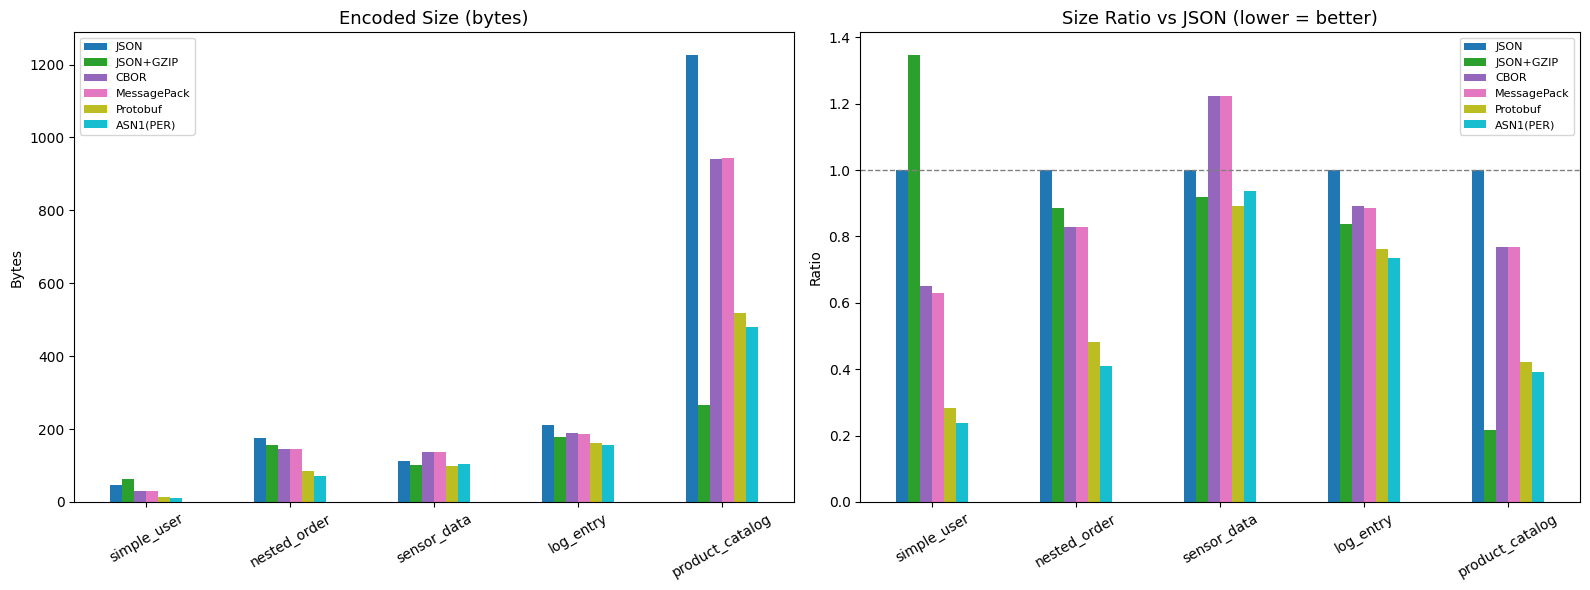

saved: comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 絶対サイズ
df.plot(kind="bar", ax=axes[0], colormap="tab10")
axes[0].set_title("Encoded Size (bytes)", fontsize=13)
axes[0].set_ylabel("Bytes")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc="upper left", fontsize=8)

# JSON比
df_ratio.plot(kind="bar", ax=axes[1], colormap="tab10")
axes[1].set_title("Size Ratio vs JSON (lower = better)", fontsize=13)
axes[1].set_ylabel("Ratio")
axes[1].set_xlabel("")
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved: comparison.png")

## ヒートマップ (JSON比)

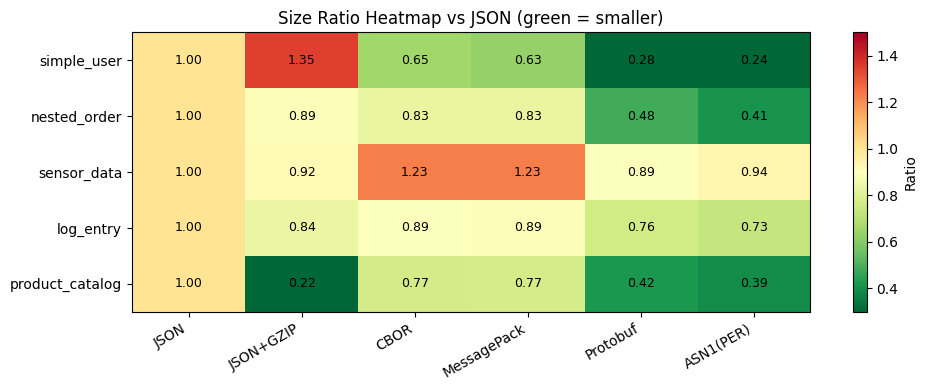

In [10]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 4))
cmap = plt.cm.RdYlGn_r
im = ax.imshow(df_ratio.values, cmap=cmap, vmin=0.3, vmax=1.5, aspect="auto")

ax.set_xticks(range(len(df_ratio.columns)))
ax.set_xticklabels(df_ratio.columns, rotation=30, ha="right")
ax.set_yticks(range(len(df_ratio.index)))
ax.set_yticklabels(df_ratio.index)
ax.set_title("Size Ratio Heatmap vs JSON (green = smaller)")

for i in range(len(df_ratio.index)):
    for j in range(len(df_ratio.columns)):
        ax.text(j, i, f"{df_ratio.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, label="Ratio")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=120, bbox_inches="tight")
plt.show()